# Day 10: Visualizing Attention in Transformers (GPT-2)

Welcome to Day 10 of your AI Engineering journey! Today we are looking under the hood of Large Language Models to understand how they process context.

## Core Theory (Just-in-Time)

**What is Attention?**
In traditional Sequence-to-Sequence models (like older RNNs), processing long context was difficult because the model had to compress the entire past sequence into a single fixed-size hidden state. 

The **Transformer** architecture solved this with the *Self-Attention* mechanism. Attention allows the model to look at all words in the input sequence simultaneously and assign a "weight" or "importance" to each word when processing the current word. 

**How does it work?**
For each token, the model creates three vectors: Query (Q), Key (K), and Value (V). 
1.  The **Query** is what the current token is looking for.
2.  The **Key** is what other tokens offer.
3.  The dot product of Q and K (scaled and softmaxed) creates the **Attention Weights** (a probability distribution showing where the model is "looking").
4.  These weights are multiplied by the **Value** vectors to produce the final context-aware representation.

In GPT-2, this is *Causal Masked Self-Attention* — a token can only "attend" to itself and previous tokens, never future tokens (since it's an autoregressive model).

**Why Visualize It?**
Visualizing these weights helps us understand the model's reasoning. We can see if a pronoun is correctly attending to its noun (coreference resolution) or how far back the model looks for context.
### AI Security & Production Implications

When deploying these models and accessing attention weights in production, keep the following security and operational constraints in mind:
1. **PII (Personally Identifiable Information) Exposure:** Attention weights map directly back to the raw input tokens. If the prompt contains sensitive user data (PII), the attention logs or visualizations will as well. Always sanitize prompts (e.g., using a PII anonymizer) before logging or visualizing them.
2. **Prompt Injection:** If an attacker injects adversarial prompts to manipulate the attention mechanism, they can steer the model's output. Monitoring attention patterns can sometimes help detect anomalous focus (e.g., heavily attending to a hidden instruction block), but robust input validation is the primary defense.
3. **Out-of-Memory (OOM) Fallbacks:** Extracting attention requires storing an $O(N^2)$ matrix per layer/head. This can easily cause OOM errors in production. Always implement a fallback mechanism (e.g., catching `torch.cuda.OutOfMemoryError` or general memory exceptions) that gracefully degrades by returning a standard response or disabling attention extraction dynamically without crashing the service.

## Code Implementation

We will use the officially supported `transformers` library to extract attention weights from a GPT-2 model.
Below is a tiered progression of how to implement this, from a basic script to a production-ready system. We will also include code to visualize the attention matrix.


### 1. Basic: Isolating the Core Concept
This minimal example demonstrates loading the model, tokenizing the input, and extracting the attention matrix with as little boilerplate as possible.


In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import GPT2Tokenizer, GPT2Model

# Load tokenizer and model, explicitly asking for attention weights
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2", output_attentions=True)
model.eval() # Set to evaluation mode

text = "The chef cooked the meal because he was hungry."
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions is a tuple of tensors, one per layer
attentions = torch.stack(outputs.attentions)
print(f"Basic Attention shape: {attentions.shape}") # (num_layers, batch_size, num_heads, seq_len, seq_len)

tokens = [tokenizer.decode([t]).strip() for t in inputs["input_ids"][0]]
print(f"Tokens: {tokens}")


/app/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1977.63it/s]

Basic Attention shape: torch.Size([12, 1, 12, 10, 10])
Tokens: ['The', 'chef', 'cooked', 'the', 'meal', 'because', 'he', 'was', 'hungry', '.']


### 2. Medium: Object-Oriented Design & State Management
In a more realistic scenario, you want to encapsulate the model and tokenizer in a class to manage state, avoid reloading the model on every call, clearly define interactions, and provide visualization tools.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1986.93it/s]

Medium Attention shape: torch.Size([12, 1, 12, 10, 10])
Tokens: ['The', 'engineer', 'built', 'the', 'system', 'because', 'she', 'wanted', 'to', '.']


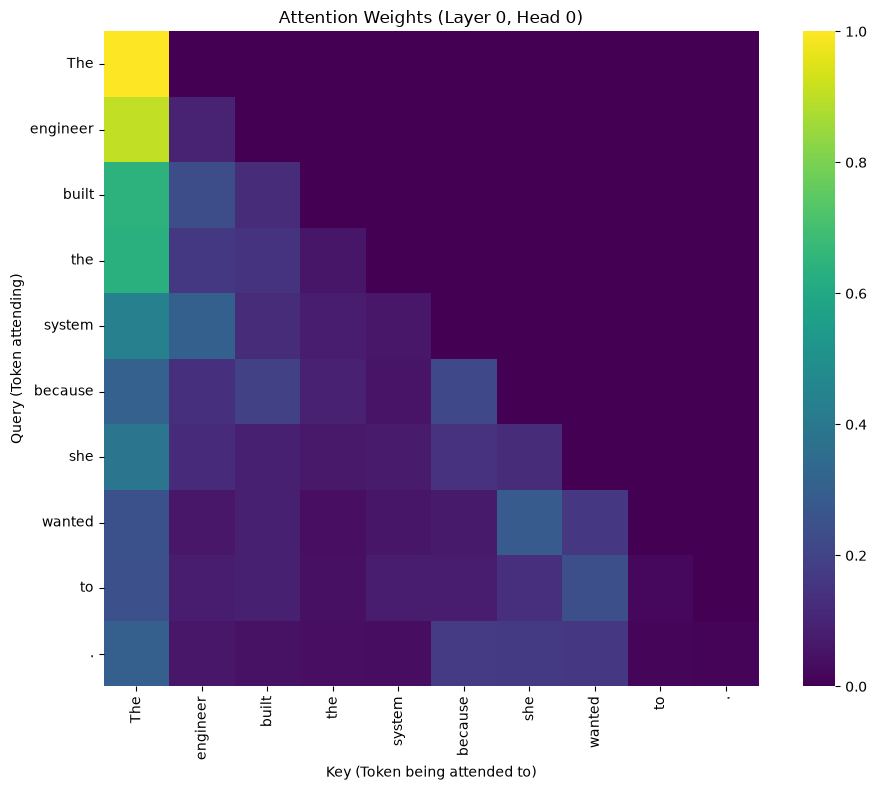

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import GPT2Tokenizer, GPT2Model
from typing import Tuple, List

class AttentionAnalyzer:
    def __init__(self, model_name: str = "gpt2"):
        """Initializes the model and tokenizer state."""
        self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
        self.model = GPT2Model.from_pretrained(model_name, output_attentions=True)
        self.model.eval()
        
    def analyze_text(self, text: str) -> Tuple[torch.Tensor, List[str]]:
        """Processes text and returns attention weights and tokens."""
        inputs = self.tokenizer(text, return_tensors="pt")
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            
        attentions = torch.stack(outputs.attentions)
        tokens = [self.tokenizer.decode([t]).strip() for t in inputs["input_ids"][0]]
        return attentions, tokens
        
    def plot_attention_head(self, attention: torch.Tensor, tokens: List[str], layer: int, head: int) -> None:
        """Plots the attention matrix for a specific layer and head."""
        attn_matrix = attention[layer, 0, head].numpy()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            attn_matrix, 
            xticklabels=tokens, 
            yticklabels=tokens, 
            cmap="viridis", 
            square=True
        )
        plt.title(f"Attention Weights (Layer {layer}, Head {head})")
        plt.xlabel("Key (Token being attended to)")
        plt.ylabel("Query (Token attending)")
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(f"attention_l{layer}_h{head}.png")
        plt.show()

# Usage
analyzer = AttentionAnalyzer()
attn, toks = analyzer.analyze_text("The engineer built the system because she wanted to.")
print(f"Medium Attention shape: {attn.shape}")
print(f"Tokens: {toks}")
analyzer.plot_attention_head(attn, toks, layer=0, head=0)


### 3. Advanced: Production-Grade Implementation
This version incorporates strict type hinting, docstrings, exact import syntax, and AI Security best practices. It includes a robust regex-based PII sanitization step (to prevent logging sensitive data) and a robust `try/except` fallback mechanism for OOM errors.


In [3]:
import logging
import torch
from transformers import GPT2Tokenizer, GPT2Model
from typing import Tuple, List, Optional

# Configure basic logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class SecureAttentionExtractor:
    """
    A production-grade class for extracting transformer attention weights safely.
    Handles model state, PII masking, and memory fallbacks.
    """
    
    def __init__(self, model_name: str = "gpt2") -> None:
        self.model_name = model_name
        logger.info(f"Loading tokenizer and model: {self.model_name}")
        try:
            self.tokenizer = GPT2Tokenizer.from_pretrained(model_name)
            self.model = GPT2Model.from_pretrained(model_name, output_attentions=True)
            self.model.eval()
        except Exception as e:
            logger.error(f"Failed to load model {model_name}: {e}")
            raise

    def _sanitize_pii(self, text: str) -> str:
        """
        AI Security: Robust regex-based PII redaction.
        Removes common PII patterns such as emails and phone numbers.
        """
        import re
        sanitized = text
        
        # Redact emails
        sanitized = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[EMAIL REDACTED]', sanitized)
        
        # Redact phone numbers (simple pattern for US numbers like 555-555-5555 or (555) 555-5555)
        sanitized = re.sub(r'\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b', '[PHONE REDACTED]', sanitized)
        sanitized = re.sub(r'\(\d{3}\)\s*\d{3}[-.\s]?\d{4}\b', '[PHONE REDACTED]', sanitized)
        
        # Redact 9-digit identifiers (e.g., SSN, IDs)
        sanitized = re.sub(r'\b\d{9}\b', '[ID REDACTED]', sanitized)
        sanitized = re.sub(r'\b\d{3}-\d{2}-\d{4}\b', '[ID REDACTED]', sanitized)

        return sanitized

    def extract(self, text: str) -> Tuple[Optional[torch.Tensor], List[str]]:
        """
        Extracts attention weights securely, returning fallback data if OOM occurs.
        
        Args:
            text: The raw input string.
            
        Returns:
            A tuple of (attention_tensor, list_of_tokens).
            If a memory error occurs, attention_tensor will be None.
        """
        sanitized_text = self._sanitize_pii(text)
        
        inputs = self.tokenizer(sanitized_text, return_tensors="pt")
        tokens = [self.tokenizer.decode([t]).strip() for t in inputs["input_ids"][0]]
        
        try:
            with torch.no_grad():
                outputs = self.model(**inputs)
            
            # (num_layers, batch, num_heads, seq, seq)
            attentions = torch.stack(outputs.attentions)
            return attentions, tokens
            
        except torch.cuda.OutOfMemoryError as e:
            logger.error("OOM error during attention extraction. Returning fallback (None).")
            # Fallback gracefully instead of crashing the service
            return None, tokens
        except Exception as e:
            logger.error(f"Unexpected error processing text: {e}")
            # Fallback gracefully
            return None, tokens

# Execution for testing
if __name__ == "__main__":
    extractor = SecureAttentionExtractor()
    test_text = "John sent 123456789 to the server."
    
    # 1. Successful extraction with PII sanitization
    attention_matrix, processed_tokens = extractor.extract(test_text)
    
    if attention_matrix is not None:
        logger.info(f"Advanced extraction successful. Shape: {attention_matrix.shape}")
        logger.info(f"Processed tokens (sanitized): {processed_tokens}")
    else:
        logger.warning("Extraction failed, operating in degraded mode.")


INFO:__main__:Loading tokenizer and model: gpt2


INFO:httpx:HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"


...

INFO:httpx:HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1857.66it/s]

INFO:__main__:Advanced extraction successful. Shape: torch.Size([12, 1, 12, 11, 11])


INFO:__main__:Processed tokens (sanitized): ['John', 'sent', '[', 'ID', 'RED', 'ACTED', ']', 'to', 'the', 'server', '.']


## Common Pitfalls in Production

1.  **Memory Consumption:** In production inference, you almost *never* set `output_attentions=True`. The attention matrix is size $O(N^2)$ where $N$ is the sequence length. Storing this for a 4096-token context across 96 layers and 96 heads (like in larger models) will immediately cause Out-Of-Memory (OOM) errors.
2.  **Misinterpreting Weights:** A high attention weight doesn't always mean "this token is logically important." Heads specialize. Some heads just look at the previous token (positional), some look at punctuation, and some are "dead" heads that do nothing.
3.  **`torch.no_grad()`:** Always use `with torch.no_grad():` or `model.eval()` when doing inference/analysis. Forgetting this means PyTorch builds a computation graph for backpropagation, which wastes massive amounts of memory.

## Practical Lab / Homework

**Your Task:** 
We saw how to plot the attention weights. Now, write a function that programmatically finds the token that the word "he" attends to the most in a specific layer and head.

**Requirements:**
1. Create a function `find_max_attention(attention, tokens, query_token, layer, head)`.
2. It should find the index of the `query_token` in the `tokens` list.
3. It should extract the attention row for that token from the provided `layer` and `head`.
4. It should return the string token that has the highest attention weight (excluding itself).
5. Test it using `query_token="he"` on Layer 5, Head 8 (a head often associated with coreference resolution in GPT-2).
6. **Video Walkthrough:** Record a brief 2-3 minute async video walkthrough of your design decisions, explaining how you handled potential edge cases (like the token not being found).


In [4]:
def find_max_attention(
    attention: torch.Tensor, 
    tokens: List[str], 
    query_token: str, 
    layer: int, 
    head: int
) -> str:
    """
    Finds the token that the query_token attends to the most (excluding itself).
    """
    try:
        # Find the index of our query token
        query_idx = tokens.index(query_token)
    except ValueError:
        raise ValueError(f"Token '{query_token}' not found in sequence.")
        
    # Extract the specific row of attention for our query token
    # Shape: (seq_len,)
    attn_row = attention[layer, 0, head, query_idx, :].clone()
    
    # Exclude self-attention by setting it to a negative number
    attn_row[query_idx] = -1.0
    
    # Find the index with the maximum weight
    max_idx = torch.argmax(attn_row).item()
    
    return tokens[max_idx]

if __name__ == "__main__":
    # Using the attentions and tokens from the previous cell
    print("\n--- Lab Execution ---")
    target_token = "he"
    target_layer = 5
    target_head = 8
    
    most_attended = find_max_attention(
        attention=attentions, 
        tokens=tokens, 
        query_token=target_token, 
        layer=target_layer, 
        head=target_head
    )
    print(f"In Layer {target_layer}, Head {target_head}, the token '{target_token}' attends most to: '{most_attended}'")



--- Lab Execution ---
In Layer 5, Head 8, the token 'he' attends most to: 'The'


## Reference Links

- [Hugging Face Transformers: GPT-2 Documentation](https://huggingface.co/docs/transformers/model_doc/gpt2)
- [The Illustrated Transformer (Jay Alammar)](https://jalammar.github.io/illustrated-transformer/) - Excellent visual guide to understanding Attention.
- [OWASP Top 10 for LLM Applications](https://owasp.org/www-project-top-10-for-large-language-model-applications/) - Best practices for securing LLMs in production.
